<a href="https://colab.research.google.com/github/Codevibes7/codef/blob/main/indian_food_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers,models
%matplotlib inline
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPool2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings

In [ ]:
print(tf.__version__)
print(tf.test.gpu_device_name())

2.19.0
/device:GPU:0


In [ ]:
import os

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!unzip "/content/drive/MyDrive/indian-food.zip" -d "/content/drive/MyDrive/"

Archive:  /content/drive/MyDrive/indian-food.zip
replace /content/drive/MyDrive/Model/__notebook_source__.ipynb? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [9]:
!ls /content/drive/MyDrive/

 AIML-23.pptx
 annotations_bundle.zip
 Certificate_209251_34_7k4sg.pdf
 chandani58.gdoc
'Chandani yadav -62.pdf'
'Chandani Yadav -62Resume- Google Docs.pdf'
'Chandani Yadav.gdoc'
'Chandani Yadav  - Google Docs.pdf'
'Chandani Yadav.gsheet'
'chandani yadav.pdf'
'Chandani Yadav - Pivot Table 1.gsheet'
 Classroom
'coffee.csv - coffee.csv.gsheet'
'Colab Notebooks'
 dataset
'Day3 report template -.docx - Google Docs.pdf'
'Day 4 report template.docx - Google Docs.pdf'
'Day 5 report template...docx - Google Docs.pdf'
'Document from Chandani'
'Excel project'
'Google AI Studio'
 images
 IMG_20250413_113711.jpg
 indian-food.zip
'INS 2.gdoc'
'INS 2.pdf'
'INS 3.gdoc'
'INS 3.pdf'
 INS4.gdoc
 INS4.pdf
'iot research paper.gdoc'
'IOTsevurity challenges research paper.gdoc'
 Model
' offer.pdf'
 rectangular_batteries
'rectangular dataset'
'report no1-1.pdf'
'Research ppt (1).pptx'
'Research ppt.pptx'
 Resume.gdoc
 rugvedi19.gdoc
 Sangeeta_Yadav_92077.pdf
 Screenshot_2025-05-14-13-46-22-61.jpg
'Security c

In [10]:
# Step 1: define variables
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 200

# Step 2: load dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/dataset/Dataset/train",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/dataset/Dataset/val",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 3996 files belonging to 20 classes.
Found 1250 files belonging to 20 classes.


In [11]:
class_names = train_ds.class_names
class_names

['burger',
 'butter_naan',
 'chai',
 'chapati',
 'chole_bhature',
 'dal_makhani',
 'dhokla',
 'fried_rice',
 'idli',
 'jalebi',
 'kaathi_rolls',
 'kadai_paneer',
 'kulfi',
 'masala_dosa',
 'momos',
 'paani_puri',
 'pakode',
 'pav_bhaji',
 'pizza',
 'samosa']

In [12]:
len(train_ds)

125

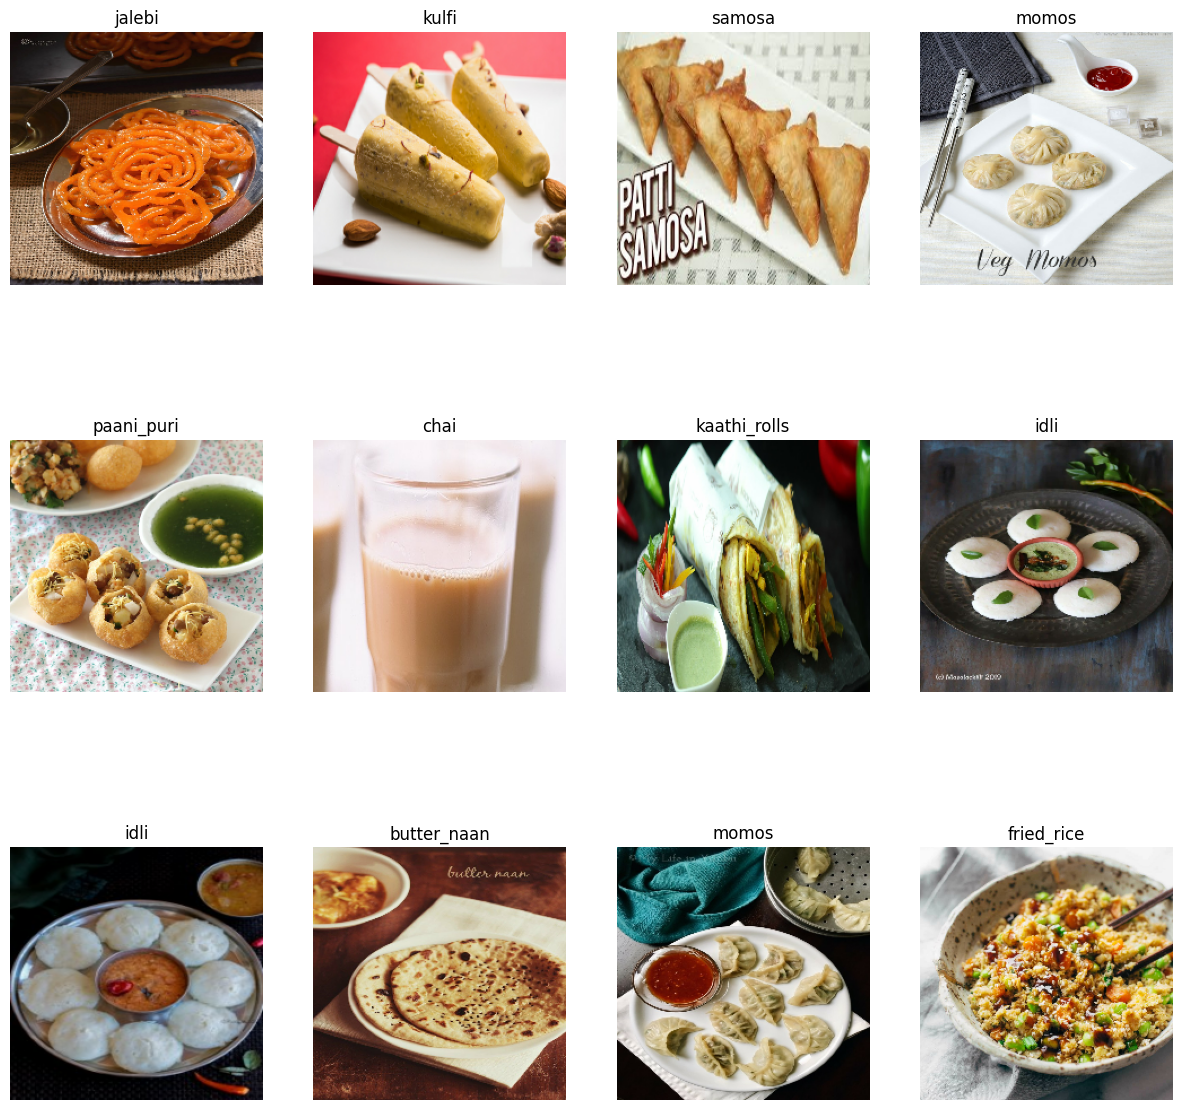

In [13]:
plt.figure(figsize=(15, 15))

for image_batch, label_batch in train_ds.take(1):
    for i in range(12):
        a = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype('uint8'))
        plt.title(class_names[label_batch[i]])
        plt.axis('off')

In [14]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [15]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

skippppppppppppppppppppppppp


In [ ]:
model = tf.keras.models.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),  # 🔥 increased
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),          # 🔥 increased
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
EPOCHS = 30

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(acc, label='train_accuracy')
plt.plot(val_acc, label='val_accuracy')
plt.legend()
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(256, 256))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)  # shape (1, 256, 256, 3)

In [ ]:
prediction = model.predict(img_array)

In [ ]:
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

print("Predicted:", predicted_class)
print("Confidence:", confidence)

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f})")
plt.axis('off')

In [ ]:
import os
model.save("Indian-food.h5")

from here efficient net


In [16]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [17]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.models.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 358ms/step - accuracy: 0.4207 - loss: 2.0080 - val_accuracy: 0.4536 - val_loss: 1.9220
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 355ms/step - accuracy: 0.4469 - loss: 1.9002 - val_accuracy: 0.4656 - val_loss: 1.8501
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 357ms/step - accuracy: 0.4757 - loss: 1.8233 - val_accuracy: 0.5232 - val_loss: 1.7017
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 354ms/step - accuracy: 0.5183 - loss: 1.7133 - val_accuracy: 0.5272 - val_loss: 1.6783
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 355ms/step - accuracy: 0.5348 - loss: 1.6328 - val_accuracy: 0.4832 - val_loss: 1.8132
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 355ms/step - accuracy: 0.5658 - loss: 1.5376 - val_accuracy: 0.5752 - val_loss: 1.5443
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 355ms/step - accuracy: 0.5943 - loss: 1.4606 - val_accuracy: 0.6200 - val_loss: 1.3995
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 355ms/step - accuracy: 0.6074 - loss: 1

In [ ]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30


ok


acurraacy


In [ ]:
print("Train Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

Train Accuracy: 0.8721221089363098
Validation Accuracy: 0.86080002784729


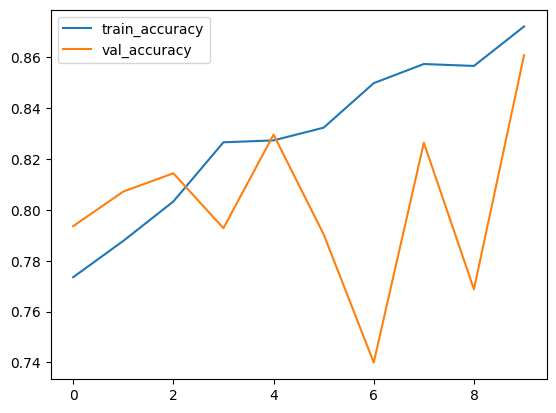

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(acc, label='train_accuracy')
plt.plot(val_acc, label='val_accuracy')
plt.legend()
plt.show()

In [ ]:
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,074,137 (49.87 MB)

 Trainable params: 4,343,184 (16.57 MB)

 Non-trainable params: 44,583 (174.16 KB)

 Optimizer params: 8,686,370 (33.14 MB)

None


In [ ]:
model.save("food_model.keras")   # ✅ new (recommended)

In [ ]:
from google.colab import files
files.download("food_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-04-04 210031.png to Screenshot 2026-04-04 210031.png


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

print("Predicted:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted: paani_puri
Confidence: 0.37456676


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

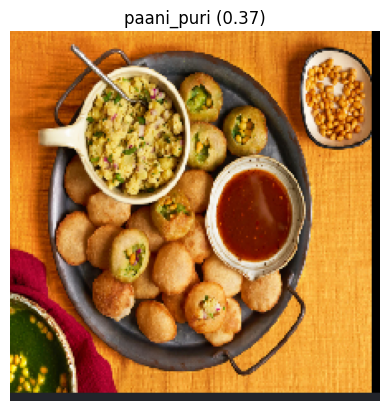

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f})")
plt.axis('off')